In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jun  3 15:13:23 2025

@author: robertbenassai
"""
import numpy as np
import matplotlib.pyplot as plt 
import csv
import scipy.optimize as opt;
# distribution of distances
import os
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.spatial import Delaunay
import networkx as nx
import math
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

0.2922448979591837
76 different source target pairs used


/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_73714/2683735558.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


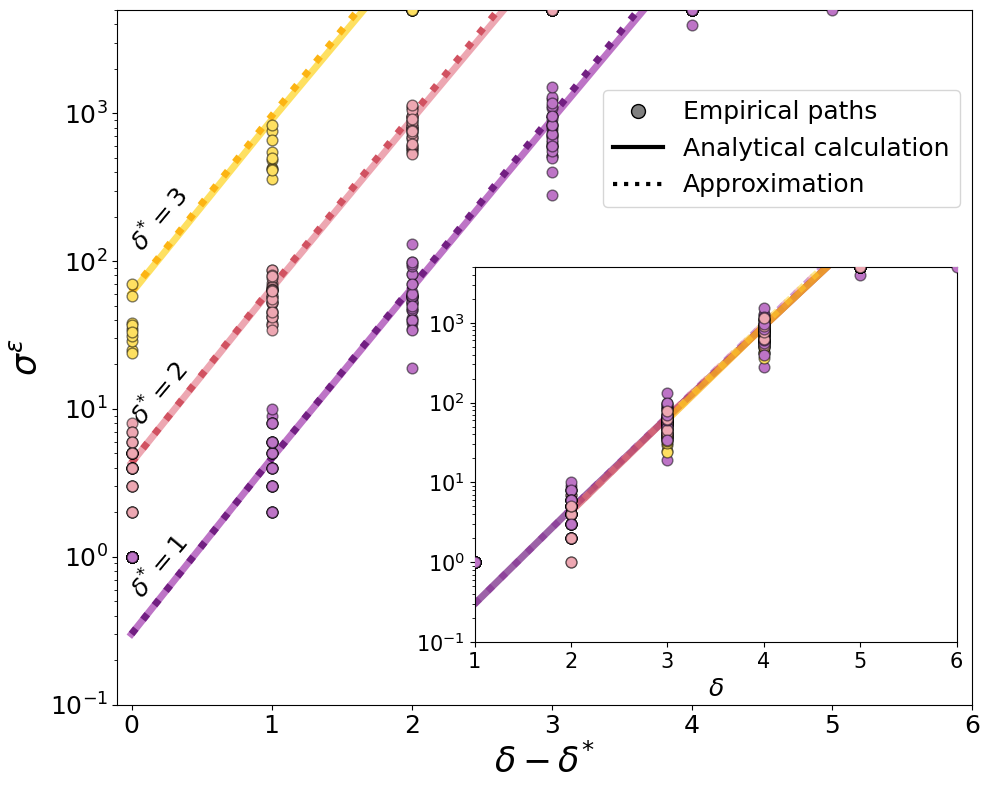

In [4]:
def function(x, a):#, b):
    # return(a*x**b)
    return(a*np.log(x))

direct = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ER_50/"
# for el in os.listdir(direct):
    
read_G = nx.Graph()
with open(direct+'ER_50.csv', 'r') as csvfile:
     
     csvreader = csv.reader(csvfile, delimiter=',')
     for row in csvreader:
         try:
             read_G.add_edge(int(row[0]), int(row[1]))
         except:
             continue
         
         
print(nx.number_of_edges(read_G)/(50*(50-1)/2))
    
dists_fname_ls = []
paths_fname_ls = []
r2_ls = []

for file in os.listdir(direct):
    
    if file.startswith("dists"):
        dists_fname_ls.append(file)
    elif file.startswith("paths"):
        paths_fname_ls.append(file)

print(len(dists_fname_ls), "different source target pairs used")

paths_fname_ls.sort()
dists_fname_ls.sort()

color_ls = cm.inferno(np.linspace(0, 0.8, 4))

color_ls_pastel_1 = np.copy(color_ls)
color_ls_pastel_1[:, :3] = color_ls_pastel_1[:, :3]** 0.3

color_ls_pastel_2 = np.copy(color_ls)
color_ls_pastel_2[:, :3] = color_ls_pastel_2[:, :3]** 0.8

a_list = []

dist_SP_ls = []
diff_heights = []

dist_distr_array = []

fig2, ax2 = plt.subplots(figsize = (10, 8))

ax2.set_ylabel(r"$\sigma^\varepsilon$", fontsize = 25)
# ax2.set_ylabel(r"rescaled $\frac{\Delta_{KSP}}{\delta_{SP}}$", fontsize = 18)
ax2.set_xlabel(r"$\delta-\delta^{*}$", fontsize = 25)
# ax3 = ax2.twinx() # instantiate a second axes that shares the same x-axis

axins = inset_axes(
    ax2,
    width="60%",   # relative to parent
    height="60%",
    bbox_to_anchor=(0.05, 0.08, 0.94, 0.9),
    bbox_transform=ax2.transAxes,
    loc="lower right")

axins.set_xlabel(r"$\delta$", fontsize = 18)
gamma = np.log((50)*0.3)
for j, fname in enumerate(dists_fname_ls):
    
    dists_ls = []
    overlap_ls = []
    
    fname2 = paths_fname_ls[j]
    
    with open(direct+fname, 'r') as csvfile, open(direct+fname2, 'r') as csvfile2:
        
        csvreader = csv.reader(csvfile, delimiter=',')
        csvreader2 = csv.reader(csvfile2, delimiter=',')
        
        for row in csvreader: # read distances
            k_dist = float(row[0])
            dists_ls.append(k_dist)
            
        for i, row in enumerate(csvreader2): # read paths and compute overlap
        
            if i == 0:
                SP = np.array([int(node) for node in row])
                prev_nodes = []
            try:
                path = np.array([int(node) for node in row])
                
            except:
                print(fname2)
                break
            intersec = np.intersect1d(path, prev_nodes)
            prev_nodes += list(path)
            prev_nodes = list(set(prev_nodes))
            
            overlap_ls.append(len(intersec)/(len(path)))

    
    d_sp = int(dists_ls[0])
    dist_SP_ls.append(dists_ls[0])
    k_ls = np.array(range(1,len(dists_ls)+1))
    dists_ls = (np.array(dists_ls)-dists_ls[0])

    # take only the distances and k values of the steps where the distance changes
    dists_filt = [
        d for k, d in enumerate(dists_ls)
        if k == 0 or dists_ls[k-1] != d
    ]

    k_ls_filt = [
        k + 1 for k in range(len(dists_ls))
        if k == len(dists_ls) - 1 or dists_ls[k] != dists_ls[k + 1]
    ]

    try:
        params, pcov = opt.curve_fit(function, k_ls_filt, dists_filt);
        y_pred = function(k_ls_filt, *params)
        r2 = r2_score(dists_filt, y_pred)
        r2_ls.append(r2)
    
        perr = np.sqrt(np.diag(pcov))
        dist_distr_array.append(dists_ls/params[0])

        ax2.scatter(dists_filt, k_ls_filt,#/params[0] , #label = 'real distance of KSP to the SP', 
                    color = color_ls_pastel_1[d_sp], s = 60, marker = 'o', 
                    linewidths=1, edgecolors=[0, 0 , 0, 0.5], zorder = 100)
        
        diff_heights.append((np.max(dists_ls/params[0]), params[0]))
        
        axins.scatter(np.array(dists_filt)+d_sp, k_ls_filt,
                      color = color_ls_pastel_1[d_sp], s = 60, marker = 'o',
                      linewidths=1, edgecolors=[0, 0 , 0, 0.5], zorder = 100)

   
    
    except(RuntimeError):
        pass
    
#% PATH DEGENERACY OF A RANDOM GRAPH OF n nodes and with connection prob. p
for sp_dist in range(1, 4):
    
    p = 0.3
    n = 50
    max_dist = n-40
    d = np.linspace(sp_dist, max_dist, max_dist-sp_dist, dtype=int) #distances
    mu = np.zeros_like(d, dtype = np.float64)
    for i, d_i in enumerate(d):
        mu[i] = math.perm(n-2, d_i-1)*p**d_i
    
    #%
    mu_sum = np.zeros_like(d, dtype = np.float64)
    
    for i in range(max_dist-sp_dist):
        mu_sum[i] = np.sum(mu[:i+1])
    

    ax2.plot(d-sp_dist, mu_sum, color = color_ls_pastel_1[sp_dist], label = r'$\delta^{*}$ ='+str(sp_dist), linewidth=5)
    
    #gamma = np.log((n-2)*p)
    gamma = np.log((n-2)*p)

    approx =((np.exp(gamma*(d+1))-1)/(np.exp(gamma)-1)-(np.exp(gamma*(sp_dist))-1)/(np.exp(gamma)-1))/(n-2)
    
    # approx2 =((np.exp(gamma*(d+1))-1)/(np.exp(gamma)-1))/(n-2)

    
    ax2.plot(d-sp_dist, approx, color = color_ls_pastel_2[sp_dist], 
             label = r'approx. $\delta^{*}$ ='+str(sp_dist), linestyle = ':', linewidth=5)

    # ax2.plot(d-sp_dist, approx2, color = color_ls[sp_dist], 
    #         label = r'approx 2. $\delta^{*}$ ='+str(sp_dist), linestyle = '--')
    
    axins.plot(d, approx, color = color_ls_pastel_1[sp_dist], linestyle = ':', linewidth=5, alpha = 0.7)
    axins.plot(d, mu_sum, color = color_ls_pastel_2[sp_dist], label = r'$\delta^{*}$ ='+str(sp_dist), linewidth=5, alpha = 0.7)

# plt.xlabel("K")
# plt.ylabel("distance")

    # a_params, a_pcov = opt.curve_fit(fun3, mu_sum[:(max_dist-sp_dist)], d-sp_dist);
    # ax2.plot(mu_sum, a_params[0]*np.log(mu_sum) + a_params[1], '-.',
    #             color = color_ls[sp_dist], label = r'y = '+str(round(a_params[0], 2))+
    #             '$log(x) + '+str(round(a_params[1], 2))+'}$')
    
    # r2 = r2_score(d-sp_dist, a_params[0]*np.log(mu_sum) + a_params[1])
    # print(a_params)
    # print(np.sqrt(np.diag(a_pcov)))
    
    # print(r2)
    
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Define custom legend entries

# Line styles
legend_lines_styles = [
    Line2D([0], [0], linestyle = '', marker='o', color='gray', alpha = 1,
            label='Empirical paths', markersize=10, markeredgecolor='black', markeredgewidth=1),
    Line2D([0], [0], linestyle='-', color='black', label='Analytical calculation', linewidth=3),
    Line2D([0], [0], linestyle=':', color='black', label='Approximation', linewidth=3)
]

# Colors

ax2.text(
    0.05, 0.75, r'$\delta^{*} = 3$',
    transform=ax2.transAxes,
    rotation=50,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="center"
)

ax2.text(
    0.05, 0.5, r'$\delta^{*} = 2$',
    transform=ax2.transAxes,
    rotation=50,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="center"
)

ax2.text(
    0.05, 0.25, r'$\delta^{*} = 1$',
    transform=ax2.transAxes,
    rotation=50,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="center"
)



# legend_lines_colors = [
#     Line2D([0], [0], linestyle='-', color=color_ls[1], label=r'$\delta^{*} = 1$'),
#     Line2D([0], [0], linestyle='-', color=color_ls[2], label=r'$\delta^{*} = 2$'),
#     Line2D([0], [0], linestyle='-', color=color_ls[3], label=r'$\delta^{*} = 3$')
# ]

# Combine and show legend
ax2.legend(fontsize = 18, handles=legend_lines_styles, loc='center right', bbox_to_anchor=(1.0, 0.8))

ax2.set_yscale('log')
axins.set_yscale('log')
# ax2.legend(fontsize = 18, ncols = 3)
ax2.tick_params(axis='both', labelsize=18)
ax2.set_ylim(0.1, 5000)
ax2.set_xlim(-0.1, 6)

axins.tick_params(axis='both', labelsize=15)
axins.set_ylim(0.1, 5000)
axins.set_xlim(1, 6)
plt.tight_layout()
plt.savefig("./figs/Expected_KSPs_ER_semilog.pdf")
plt.show()

In [94]:
def function(x, a, b):
    # return(a*x**b)
    # return a*np.log(x)
    return (a*x)

def function2(x, a):
    # return(a*x**b)
    return a*np.log(x)
    #return np.exp(x*a)

def function3(x, a , ln_b):
    return a*x + ln_b


def fun2(x, a, r):
    return r*x**a

def write_graph_to_csv(G, filename = 'graph.csv', weight = 'length'):
    # Open a CSV file in write mode
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+filename, 
              'w', newline='') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'vertex2', 'edge_weight'])
    
        # Write edges and their weights to the CSV file
        for u, v, w in G.edges(data=weight):
            csvwriter.writerow([u, v, w])
            
    print('Graph has been written to '+filename)

def write_positions_to_file(pos: dict, path:str):
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+path, 'w') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'x', 'y'])
    
        # Write edges and their weights to the CSV file
        for i, xy in pos.items():
            csvwriter.writerow([i, xy[0], xy[1]])
# n_disc_ls = []
# prob_ls = []
# mean_dists = []
# direct = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/osm_bcn_files/osm_bcn_distrs/path_distr/eix/"
# direct = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/time_testing_delaunays/path_distr/del_1100/"
# direct = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/scale_free/"
direct_p = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/osm_bcn_files/osm_bcn_distrs/path_distr/cv_new/paths/"
direct_d = "/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/osm_bcn_files/osm_bcn_distrs/path_distr/cv_new/dists/"


In [96]:
# READ PATH LISTS AND DISTANCE LISTS

dists_fname_ls = []
paths_fname_ls = []

for file in os.listdir(direct_d):
    if "dists" in file:
        dists_fname_ls.append(file)
for file in os.listdir(direct_p):
    if "paths" in file:
        paths_fname_ls.append(file)

paths_fname_ls.sort()
dists_fname_ls.sort()
max_val = 0
gamma_ls = []
a_list = []
dist_SP_ls = []
diff_heights = []
dist_distr_array = []

dist_ls_accum = []

for j, fname in enumerate(dists_fname_ls):
    
    dists_ls = []
    overlap_ls = []
    fname2 = paths_fname_ls[j]
    k_ls = []
    #with open(direct+fname, 'r') as csvfile, open(direct+fname2, 'r') as csvfile2:#uncomment for all except for cv
    with open(direct_d+fname, 'r') as csvfile, open(direct_p+fname2, 'r') as csvfile2: #uncomment for cv
        csvreader = csv.reader(csvfile, delimiter=',')
        csvreader2 = csv.reader(csvfile2, delimiter=',')
        it = 1
        for row in csvreader: # read distances

            k_dist = float(row[0])
            dists_ls.append(k_dist)
            k_ls.append(it)     
            it += 1

        if len(dists_ls) <2:
            continue

            
        for i, row in enumerate(csvreader2): # read paths and compute overlap
        
            if i == 0:
                SP = np.array([int(node) for node in row])
                prev_nodes = []
            try:
                path = np.array([int(node) for node in row])
            except:
                break
            intersec = np.intersect1d(path, prev_nodes)
            prev_nodes += list(path)
            prev_nodes = list(set(prev_nodes))
            
            overlap_ls.append(len(intersec)/(len(path)))    

    # dists_ls = (np.array(dists_ls)-dists_ls[0])/dists_ls[0]  # to km
    dist_SP_ls.append(dists_ls[0]/1000)
    dists_ls = (np.array(dists_ls)-dists_ls[0])/1000  # to km

    # k_ls = np.array(range(1,len(dists_ls)+1))
    # dists_ls = (dists_ls-dists_ls[0])/dists_ls[0]
    if max(dists_ls) > max_val:
        max_val = max(dists_ls)
    dist_SP_ls_2= np.sqrt(2*np.array(dists_ls)**4-dists_ls[0]**2*np.array(dists_ls)**2*np.pi**2)
    dist_ls_accum.append(dists_ls)
        
    try:
        params, pcov = opt.curve_fit(function3, dists_ls, np.log(k_ls));

        gamma_ls.append(params[0])
        a_list.append(params[1])
        perr = np.sqrt(np.diag(pcov))

        
        diff_heights.append((np.max(dists_ls/params[0]), params[0]))

    except(RuntimeError):
        pass

    if j == 99:
        break


[4.01046, 3.54252, 1.5975, 1.7568599999999999, 2.25474, 1.4899200000000001, 0.782971, 1.0314, 3.7880100000000003, 3.43827, 4.251180000000001, 3.5966, 3.60838, 3.0768400000000002, 3.38385, 3.85194, 1.0769900000000001, 2.93848, 3.36477, 3.4689099999999997, 4.2783999999999995, 4.181850000000001, 3.31274, 3.19543, 3.31419, 4.179930000000001, 3.9163200000000002, 1.47597, 2.66184, 3.25702, 0.274964, 2.08214, 0.406763, 0.31410000000000005, 0.525784, 1.52329, 1.65281, 0.21571, 0.268068, 2.12906, 2.52529, 2.11157, 4.0841199999999995, 1.71799, 1.63669, 1.46297, 1.7001700000000002, 1.64422, 1.15285, 1.58979, 1.59809, 0.257274, 0.259652, 0.108771, 0.667918, 1.45622, 3.20186, 0.944303, 0.406045, 0.29955000000000004, 0.35484899999999997, 1.59198, 0.210566, 1.87525, 1.9441700000000002, 1.60774, 2.2781100000000003, 1.16794, 2.20709, 1.58792, 1.2493800000000002, 1.47469, 2.21277, 3.4190500000000004, 1.91279, 1.55597, 1.0986600000000002, 3.01443, 0.72614, 0.838425, 1.85121, 0.26499599999999995, 1.280930

/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_1589/2788796404.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_1589/2788796404.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_1589/2788796404.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


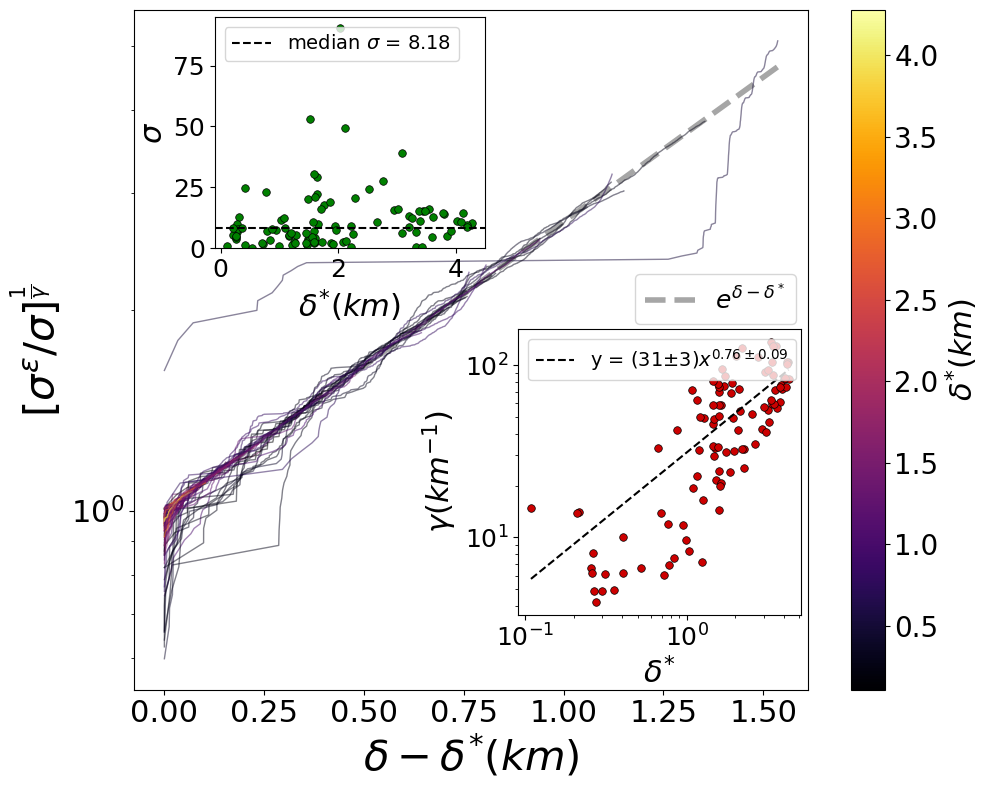

In [99]:
# PLOT
print(dist_SP_ls)
fig, ax = plt.subplots(figsize = (10, 8))

# fig, ax1 = plt.subplots(figsize = (10, 8))
ax2 = inset_axes(
    ax,
    width="42%",   # relative to parent
    height="42%",
    loc = "lower right",
    bbox_to_anchor=(0, 0.1, 1, 1),
    bbox_transform=ax.transAxes)


#ax2.set_xlabel(r"$\delta^{*} (km)$", fontsize = 22)
ax2.set_xlabel(r"$\delta^{*}$", fontsize = 22)
ax2.set_ylabel(r"$\gamma (km^{-1})$", fontsize = 22)
#ax2.set_ylabel(r"$\gamma$", fontsize = 22)
ax2.tick_params(axis='both', which='major', labelsize=18)

ax.tick_params(axis='both', which='major', labelsize=22)

ax.set_ylabel(r"$\left[\sigma^{\varepsilon}/\sigma\right ]^\frac{1}{\gamma}$", fontsize = 30)
ax.set_xlabel(r"$\delta-\delta^{*} (km)$", fontsize = 30)
#ax.set_xlabel(r"$\delta-\delta^{*}$", fontsize = 30)

ax3 = inset_axes(
    ax,
    width="40%",   # relative to parent
    height="34%",
    loc = "upper left",
    bbox_to_anchor=(0.11, 0, 1, 1),
    bbox_transform=ax.transAxes)

#ax3.set_xlabel(r"$\delta^{*}$", fontsize = 22)
ax3.set_xlabel(r"$\delta^{*}(km)$", fontsize = 22)
ax3.set_ylabel(r"$\sigma$", fontsize = 22)
ax3.tick_params(axis='both', which='major', labelsize=18)

cmap = plt.get_cmap('inferno')
norm = mcolors.Normalize(vmin=np.min(dist_SP_ls), vmax=np.max(dist_SP_ls))
# norm = mcolors.Normalize(vmin=min(gamma_ls), vmax=max(gamma_ls))

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])   # required

for i, dist_list in enumerate(dist_ls_accum):
    # get the colors from the shortest path lengths
    color = cmap((dist_SP_ls[i]-min(dist_SP_ls))/ (max(dist_SP_ls)-min(dist_SP_ls)))

    #color = cmap((gamma_ls[i]-min(gamma_ls))/ (max(gamma_ls)-min(gamma_ls)))

    # sc = ax.scatter(dist_list, ((np.arange(len(dist_list))+1)/np.exp(a_list[i]))**(1/gamma_ls[i]), 
    #             c = color, s = 1, marker = 'o', alpha=0.1)
    dists_filt = [
        d for k, d in enumerate(dist_list)
        if k == 0 or dist_list[k-1] != d
    ]

    k_ls_filt = [
        k + 1 for k in range(len(dist_list))
        if k == len(dist_list) - 1 or dist_list[k] != dist_list[k + 1]
    ]

    sc = ax.plot(dists_filt, (k_ls_filt/np.exp(a_list[i]))**(1/gamma_ls[i]), 
                c = color, linewidth = 1, ls = '-', alpha=0.5)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$\delta^{*} (km)$', fontsize=22)
#cbar.set_label(r'$\delta^{*}$', fontsize=22)
cbar.ax.tick_params(labelsize=20)
    

lins = np.linspace(0, max_val, 100)
ax.plot(lins, np.exp(lins), 
        c = 'gray', ls = '--', linewidth = 4, alpha = 0.7, label = r'$e^{\delta - \delta^*}$', zorder = 0)



a_params, a_pcov = opt.curve_fit(fun2, dist_SP_ls, gamma_ls);

ax2.scatter(dist_SP_ls, gamma_ls, #label = 'real distance of KSP to the SP', 
            color = '#CC0000', s = 30, marker = 'o', edgecolors='k', linewidth=0.5)

ds_ls = np.linspace(min(dist_SP_ls), max(dist_SP_ls), 100)
# ax1.plot(ds_ls, np.exp(a_params[1])*np.array(ds_ls)**a_params[0], #label = 'real distance of KSP to the SP', 
#             color = 'blue', label = r'y = '+str(round(np.exp(a_params[1]), 2))+
#             '$x^{'+str(round(a_params[0], 2))+'}$')

ax2.plot(ds_ls, a_params[1]*np.array(ds_ls)**a_params[0], ls = '--', #label = 'real distance of KSP to the SP', 
            color = 'k', label = r'y = ('+str(int(a_params[1]))+'$\pm$'+str(int(np.sqrt(np.diag(a_pcov)[1])))+
            ')$x^{'+str(round(a_params[0], 2))+'\pm'+str(round(np.sqrt(np.diag(a_pcov)[0]), 2))+'}$')

residuals = gamma_ls - fun2(dist_SP_ls, *a_params)

# fig4, ax4 = plt.subplots(figsize = (10, 8))
# # plot histogram of residuals
# ax4.hist(residuals, bins = 20, color = '#CC0000', alpha = 0.7)
# ax4.set_xlabel('Residuals', fontsize = 18)
# ax4.set_ylabel('Frequency', fontsize = 18)
# ax4.set_title(r'Histogram of Residuals for $\gamma$ vs. $\delta^{*}$', fontsize = 20)
# plt.show()

plt.tight_layout()

ax2.set_yscale('log')
ax2.set_xscale('log')

ax.set_yscale('log')
ax2.legend(fontsize = 14, loc = "upper left")
ax.legend(fontsize = 18, loc = 'right', bbox_to_anchor=(0, 0.075, 1, 1))
ax3.scatter(dist_SP_ls, np.exp(a_list), #label = 'real distance of KSP to the SP', 
            color = 'g', s = 30, marker = 'o', edgecolors='k', linewidth=0.5)
ax3.axhline(np.median(np.exp(a_list)), color = 'black', ls = '--', label = r'median $\sigma$ = '+str(round(np.median(np.exp(a_list)), 2)))
ax3.legend(fontsize = 14, loc = "upper left")
ax3.set_ylim(0, 95)
plt.tight_layout()
plt.tight_layout()
plt.savefig("./figs/Rescaled_KSP_distr_CV.pdf")
plt.show()



## PLOT DELAUNAY GRAPH


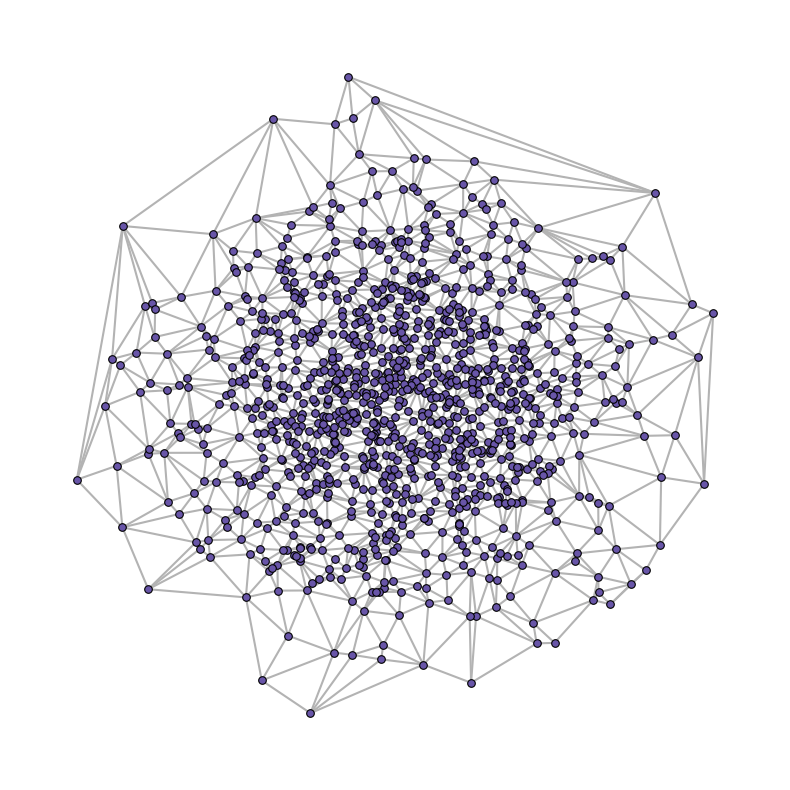

In [100]:

# x,y coords of points
nodes_cl1 = 1100
clust_1 = np.random.normal(0, 2, size=(nodes_cl1, 2))

# clusters = np.concatenate((clust_1, clust_2), axis=0)
tri = Delaunay(clust_1)

# create a set for edges that are indexes of the points
edges = set()
# for each Delaunay triangle
graph = nx.Graph()
for path in tri.simplices:
    nx.add_path(graph, path)

# make a graph based on the Delaunay triangulation edges

# plt.figure()
# plot graph
# dictionary of node:position
pointIDXY = dict(zip(range(len(clust_1)), clust_1))
# nx.set_node_attributes(graph, pointIDXY, name='pos')
nx.set_node_attributes(graph, pointIDXY, name='pos')

edge_lens = {edge: np.linalg.norm(pointIDXY[edge[1]] - pointIDXY[edge[0]]) for edge 
              in graph.edges}

nx.set_edge_attributes(graph, edge_lens, name = 'length')

# nx.set_edge_attributes(graph, dict().fromkeys(graph.edges, 1), name = 'length')


plt.figure(figsize=(8, 8))

nx.draw_networkx_edges(
    graph,
    pos=pointIDXY,
    edge_color="0.7",
    width=1.5
)

nx.draw_networkx_nodes(
    graph,
    pos=pointIDXY,
    node_size = 30,
    node_color="#6855A8",
    edgecolors="black",
    linewidths=0.8
)

plt.axis("off")
plt.tight_layout()
plt.savefig("./figs/Delaunay_graph.png", dpi=300)
plt.show()


## READ AND PLOT CIUTAT VELLA AND EIXAMPLE GRAPHS

In [101]:
import geopandas as gpd
import pandas as pd
def distr_to_nx(distr_ind:int, path_edges: str, path_distr: str, edge_attr 
                = np.empty((0,)), name :str = 'length', 
                path_nodes: str = '/Users/robertbenassai/Documents/UOC/project_HHD/xarxaneta/data/barcelona/nodes_clean_net_willum.shp'):
    
    # edges and nodes of the whole graph
    bcn_edges = gpd.read_file(path_edges, crs="EPSG:25831")


    bcn_nodes = gpd.read_file(path_nodes,
                          crs="EPSG:25831")
    
    if distr_ind == 0: # graph of the entire city
    
        # initialize graph of the district
        distr = nx.DiGraph()
        distr.add_nodes_from(pd.to_numeric(bcn_nodes['uid'], downcast='integer'))
        
        ind_to_pos = {}
        
        for i in range(len(bcn_nodes)):
            
            pos = (bcn_nodes.loc[i,'geometry'].x, bcn_nodes.loc[i,'geometry'].y) 
            
            if np.all(pos not in ind_to_pos.values()):
                
                ind_to_pos[int(bcn_nodes.loc[i,'uid'])] = pos
                
            else:
                distr.remove_node(int(bcn_nodes.loc[i,'uid']))
        
        # ind_to_pos = {int(bcn_nodes.loc[i,'uid']):(bcn_nodes.loc[i,'geometry'].x,
        #                                       bcn_nodes.loc[i,'geometry'].y) 
        #               for i in range(len(bcn_nodes))}
    
        for i, j in zip(bcn_edges['i'], bcn_edges['j']):
            
            distr.add_edge(int(i), int(j), length =\
                            np.linalg.norm(np.array(ind_to_pos[int(i)]) - 
                                          np.array(ind_to_pos[int(j)])))

                
        # for e in bcn_edges['to_from']:
        #     if e == None:
        #         continue
        #     ind = ''
        #     i = ''
        #     for a in e:
                
        #         if a.isdigit():
        #             ind += a
        #         if a == ',':
        #             i = int(ind)
        #             ind = ''
        #     j = int(ind)
            
        #     # print(i, j)
            
        #     if i == '' or j == '' or i == j: #sometimes edges only have 1 node or are self-edges
        #         continue
            
        #     if i not in distr.nodes or j not in distr.nodes:
        #         continue
            
        #     distr.add_edge(int(i), int(j), length =\
        #                     np.linalg.norm(np.array(ind_to_pos[int(i)]) - 
        #                                   np.array(ind_to_pos[int(j)])))

        #     i = j = ''
            
        
    else: # get the graph of a given district

        # districts
        bcn_distr = gpd.read_file(path_distr,
                                  crs="EPSG:25831")
        
        # joined dataframes (districts and nodes)
        nodes_w_distr = gpd.sjoin(bcn_nodes, bcn_distr,
                                how="left", predicate='within')
        
        # select only the nodes of the given district
        distr_df = nodes_w_distr.loc[nodes_w_distr['DISTRICTE'] == 
                                     "{:02d}".format(distr_ind)]
        
        # initialize graph of the district
        distr = nx.DiGraph()
        distr.add_nodes_from(distr_df['uid'])
        ind_to_pos = {nodes_w_distr.loc[i,'uid']:(nodes_w_distr.loc[i,'geometry'].x,
                                              nodes_w_distr.loc[i,'geometry'].y) for i in 
                      range(len(nodes_w_distr))}
    
    
        for i, j in zip(bcn_edges['i'], bcn_edges['j']):
            if i and j in distr.nodes:
                distr.add_edge(int(i), int(j), length =\
                           np.linalg.norm(np.array(ind_to_pos[int(i)]) - 
                                          np.array(ind_to_pos[int(j)])))

        if edge_attr.size != 0:
            print(edge_attr)
            new_attr = {}
            
            for i, j in zip(bcn_edges['i'], bcn_edges['j']):
                if i and j in distr.nodes:
                    new_attr[(int(i),int(j))] = edge_attr[int(i), int(j)]
            
            nx.set_edge_attributes(distr, new_attr, name = name)
            
    
    print('checking for disconnected components...')
    remove_nodes = list(nx.connected_components(distr.to_undirected()))
    
    print('total number of connected components', len(remove_nodes))
        
    
    remove_nodes.remove(max(remove_nodes, key = len))
    for node_set in remove_nodes:
        distr.remove_nodes_from(node_set)
        

    #remove nodes of degree 1:
    while True:
        
        deg_1_nodes = [i for i,deg in dict(nx.degree(distr)).items() if deg == 1]
        
        if len(deg_1_nodes) == 0:
            break
        distr.remove_nodes_from(deg_1_nodes)
    
    #checking for self loops
    self_loops = []
    print('checking for self loops and multiedges...')
    for edge in distr.edges:
        if edge[0] == edge[1]:
            print('self loop found', edge)
            self_loops.append(edge)
        #remove multiedges
        if (edge[1], edge[0]) in distr.edges:
            if edge[0]>edge[1]:# remove only one of the edges
                self_loops.append(edge)
    distr.remove_edges_from(self_loops)
    
    nx.set_node_attributes(distr, ind_to_pos, name = 'pos')
    
    #relabeling nodes to ascending order
    
    dict_relabel = {node: i for i, node in enumerate(sorted(distr.nodes))}
    nx.relabel_nodes(distr, dict_relabel, copy = False)    
    ind_to_pos_upd = {dict_relabel[node]: ind_to_pos[node] for node in 
                      dict_relabel.keys()}
    
    # print('plotting final graph...')

    # f, ax = plt.subplots(figsize=(10, 8))
    # nx.draw(distr, pos = ind_to_pos_upd, node_size = 2, ax = ax, with_labels=False)
    
    print('total number of nodes: ', len(distr.nodes))

    return(distr, ind_to_pos_upd)


In [120]:
# 1 for ciutat vella and 2 for eixample
distr_ind = 2
path_bcn = '/Users/robertbenassai/Documents/UOC/project_HHD/xarxaneta/data/barcelona/edges_clean_net_willum.shp'
path_distr = '/Users/robertbenassai/Documents/UOC/project_HHD/BCN_UNITATS_ADM/0301040100_Districtes_UNITATS_ADM.shp'

bcn_graph, ind_to_pos = distr_to_nx(distr_ind, path_bcn, path_distr)

checking for disconnected components...
total number of connected components 59
checking for self loops and multiedges...
total number of nodes:  3571


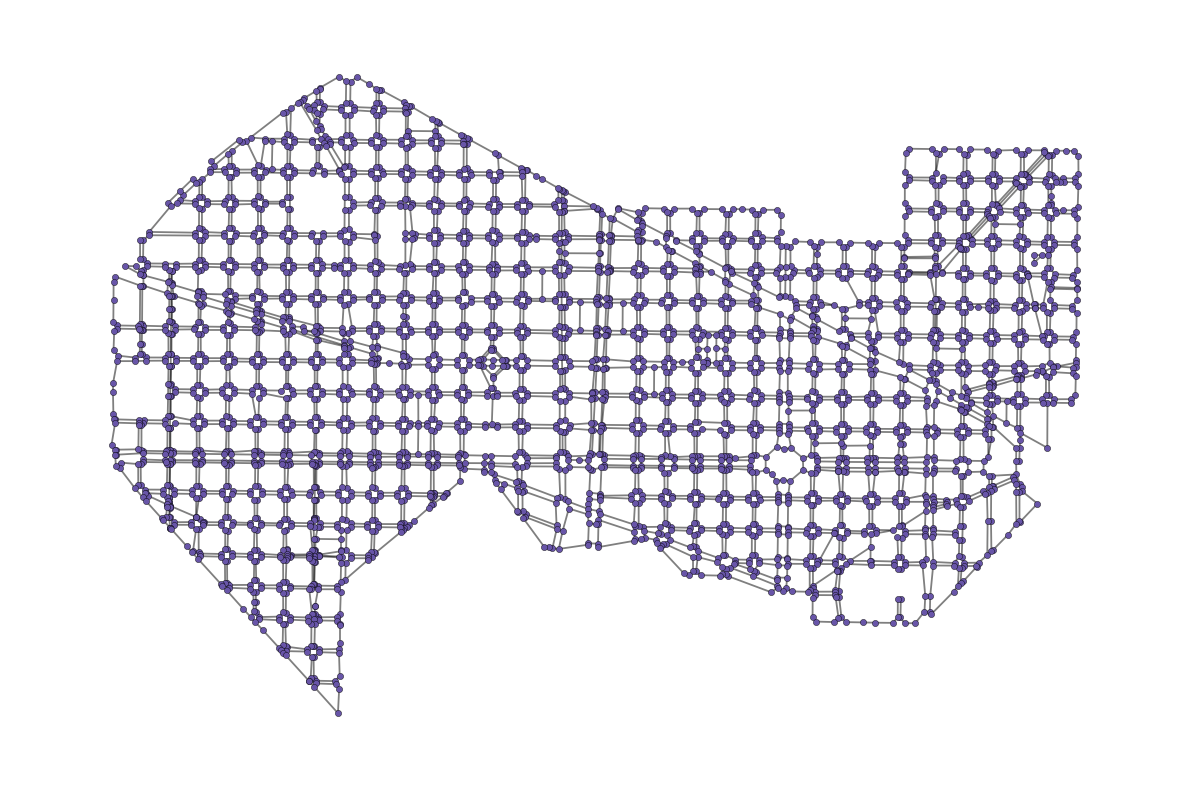

In [132]:
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.set_aspect("auto")

# ---- map underneath ----
import contextily as ctx

import numpy as np

def rotate_points(pos, angle_deg, center=None):
    angle = np.deg2rad(angle_deg)
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])

    coords = np.array(list(pos.values()))

    if center is None:
        center = coords.mean(axis=0)

    rotated = (coords - center) @ R.T + center
    return dict(zip(pos.keys(), rotated))


ind_to_pos_rot = rotate_points(ind_to_pos, angle_deg=-45)


# ---- edges (no arrows) ----
nx.draw_networkx_edges(
    bcn_graph,
    pos=ind_to_pos_rot,
    ax=ax,
    arrows=False,
    edge_color="k",
    width=1.3,
    alpha=0.5
)

# ---- nodes ----
nx.draw_networkx_nodes(
    bcn_graph,
    pos=ind_to_pos_rot,
    ax=ax,
    node_size=20,
    node_color="#6855A8",
    edgecolors="black",
    linewidths=0.3,
)

# ctx.add_basemap(
#     ax,
#     source=ctx.providers.CartoDB.PositronNoLabels,
#     alpha=0.3,
#     zorder=-1,
#     crs="EPSG:25831",
# )

plt.axis("off")
plt.tight_layout()
plt.savefig("./figs/BCN_EIX_graph.png", dpi=300)
plt.show()


Graph has been written to /scale_free/BA_m2_n500.csv


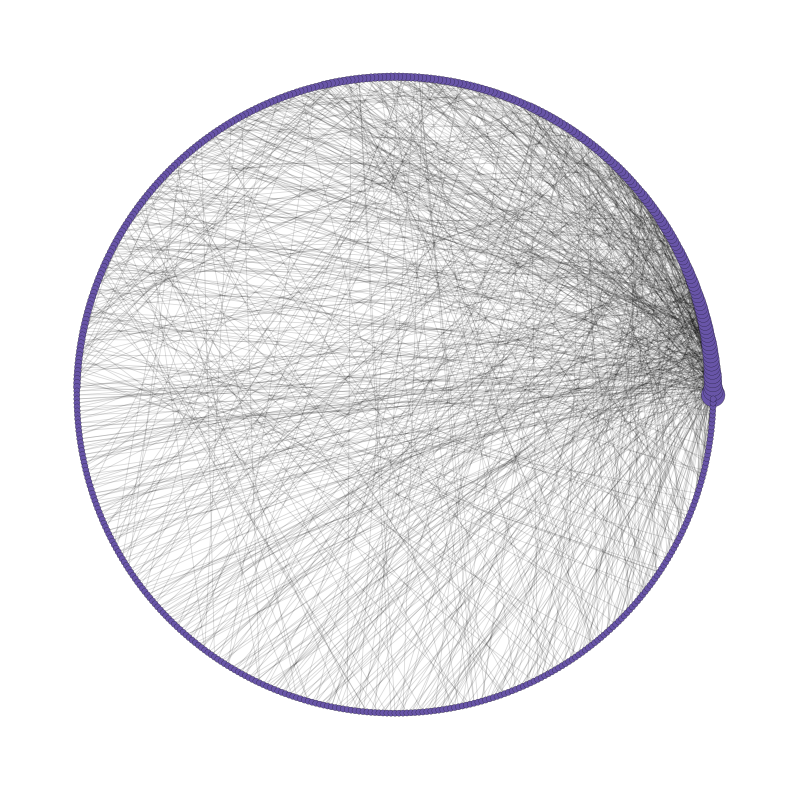

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

n = 500
m = 2
BA = nx.barabasi_albert_graph(n, m, seed = 7)

lens = np.ones(len(BA.edges))
nx.set_edge_attributes(BA, dict(zip(BA.edges, lens)), name = 'length')
write_graph_to_csv(BA, filename = '/scale_free/BA_m2_n500.csv', weight = 'length')

# degrees
deg = dict(BA.degree())

# sort nodes by decreasing degree
nodes_sorted = sorted(BA.nodes(), key=lambda v: deg[v], reverse=True)

# circular layout preserves order
pos = nx.circular_layout(nodes_sorted)

# node sizes proportional to degree
node_sizes = 8 + 6 * np.array([deg[v] for v in nodes_sorted])

fig, ax = plt.subplots(figsize=(8, 8))

# edges
nx.draw_networkx_edges(
    BA, pos, ax=ax,
    width=0.6,
    alpha=0.15
)

# nodes
nx.draw_networkx_nodes(
    BA, pos, ax=ax,
    nodelist=nodes_sorted,
    node_size=node_sizes,
    node_color="#6855A8",
    edgecolors="black",
    linewidths=0.15
)

ax.set_axis_off()
plt.tight_layout()
plt.savefig("./figs/Scale_free_BA_graph.png", dpi=300)
plt.show()

